# Reproducing the Rectified Flow Baseline

## Goal

The purpose of this notebook is to reproduce the original **minRF** implementation before introducing any modifications.

The notebook verifies that:

- the repository runs successfully,
- the model can be trained,
- samples can be generated,
- generated trajectories can be saved,
- the learned flow can be visualized.

This serves as the baseline for all subsequent interpolation experiments.

### Get Repository

In [1]:
%cd /content/minRF_interpolation

import os

print(os.getcwd())

!pwd

[Errno 2] No such file or directory: '/content/minRF_interpolation'
/content
/content
/content


### Verify Repository

In [2]:
!ls
!grep -n "Save sampled flow trajectories" rf.py

sample_data


grep: rf.py: No such file or directory


### Create Output Directory

In [ ]:
import os

os.makedirs("contents", exist_ok=True)

### Disable Wandb

In [ ]:
os.environ["WANDB_MODE"] = "disabled"

### Train Model

In [5]:
!python rf.py
import os

print("Current directory:", os.getcwd())
print("Contents exists:", os.path.exists("contents"))

!ls -la

python3: can't open file '/content/rf.py': [Errno 2] No such file or directory


Current directory: /content
Contents exists: True
total 20
drwxr-xr-x 1 root root 4096 Aug  3 22:32 .
drwxr-xr-x 1 root root 4096 Aug  3 22:12 ..
drwxr-xr-x 4 root root 4096 Jun  4 13:39 .config
drwxr-xr-x 2 root root 4096 Aug  3 22:32 contents
drwxr-xr-x 1 root root 4096 Jun  4 13:39 sample_data


### Load Saved Flow Trajectory

The stored trajectory contains intermediate states generated by integrating the learned velocity field from Gaussian noise towards the data distribution.

In [6]:
import torch

trajectory = torch.load("contents/trajectory_99.pt")

print(f"Trajectory length: {len(trajectory)}")
print(f"Tensor shape: {trajectory[0].shape}")

FileNotFoundError: [Errno 2] No such file or directory: 'contents/trajectory_99.pt'

### Load saved checkpoint

In [ ]:
checkpoint = torch.load(
    "contents/checkpoint_99.pt",
    map_location="cpu"
)

print("Checkpoint loaded successfully")
print("Number of parameters:", len(checkpoint))

Checkpoint loaded successfully
Number of parameters: 121


### Static Visualization


The following visualization shows several representative states along the learned flow trajectory, illustrating how random noise is gradually transformed into a recognizable digit.

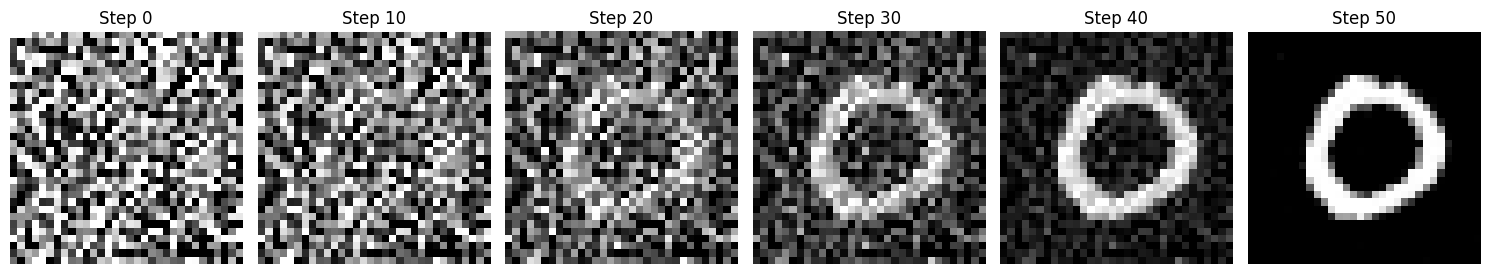

In [ ]:
import matplotlib.pyplot as plt

# Select representative flow steps
steps = [0, 10, 20, 30, 40, 50]

fig, axes = plt.subplots(1, len(steps), figsize=(15, 3))

for ax, step in zip(axes, steps):
    # First sample from the batch
    img = trajectory[step][0]

    # Undo normalization: [-1, 1] -> [0, 1]
    img = img * 0.5 + 0.5
    img = img.clamp(0, 1)

    ax.imshow(img.squeeze().cpu(), cmap="gray")
    ax.set_title(f"Step {step}")
    ax.axis("off")

plt.tight_layout()
plt.show()

### Animated Visualization

The animation displays the complete trajectory generated by the learned Rectified Flow model. It provides an intuitive view of the continuous transformation from noise to the final sample.

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

fig, ax = plt.subplots(figsize=(4, 4))

def update(step):
    ax.clear()

    # First sample from the batch
    img = trajectory[step][0]

    # Undo normalization: [-1, 1] -> [0, 1]
    img = img * 0.5 + 0.5
    img = img.clamp(0, 1)

    ax.imshow(img.squeeze().cpu(), cmap="gray")
    ax.set_title(f"Flow Step {step}/{len(trajectory)-1}")
    ax.axis("off")


animation = FuncAnimation(
    fig,
    update,
    frames=len(trajectory),
    interval=100,
)

plt.close(fig)

HTML(animation.to_jshtml())

In [ ]:
!ls -lh contents

total 160M
-rw-r--r-- 1 root root 971K Aug  3 13:00 51.gif
-rw-r--r-- 1 root root 967K Aug  3 13:00 51_ln.gif
-rw-r--r-- 1 root root  14K Aug  3 13:00 51_ln.png
-rw-r--r-- 1 root root  16K Aug  3 13:00 51.png
-rw-r--r-- 1 root root 2.4M Aug  3 13:02 checkpoint_0.pt
-rw-r--r-- 1 root root 2.4M Aug  3 13:17 checkpoint_10.pt
-rw-r--r-- 1 root root 2.4M Aug  3 13:32 checkpoint_20.pt
-rw-r--r-- 1 root root 2.4M Aug  3 13:46 checkpoint_30.pt
-rw-r--r-- 1 root root 2.4M Aug  3 14:01 checkpoint_40.pt
-rw-r--r-- 1 root root 2.4M Aug  3 14:16 checkpoint_50.pt
-rw-r--r-- 1 root root 2.4M Aug  3 14:31 checkpoint_60.pt
-rw-r--r-- 1 root root 2.4M Aug  3 14:46 checkpoint_70.pt
-rw-r--r-- 1 root root 2.4M Aug  3 15:01 checkpoint_80.pt
-rw-r--r-- 1 root root 2.4M Aug  3 15:16 checkpoint_90.pt
-rw-r--r-- 1 root root 2.4M Aug  3 15:29 checkpoint_99.pt
-rw-r--r-- 1 root root 1.1M Aug  3 13:00 cifar_63.gif
-rw-r--r-- 1 root root  33K Aug  3 13:00 cifar_63.png
-rw-r--r-- 1 root root 969K Aug  3 13:02 sampl

In [ ]:
!zip outputs.zip \
contents/checkpoint_99.pt \
contents/trajectory_99.pt \
contents/sample_99.gif \
contents/sample_99_last.png

updating: contents/sample_99_last.png (deflated 2%)
updating: contents/sample_99.gif (deflated 7%)
updating: contents/trajectory_99.pt (deflated 10%)
updating: contents/checkpoint_99.pt (deflated 9%)


In [ ]:
# Save to Google Drive (recommended – reliable alternative to browser download)
from google.colab import drive
import shutil, os

drive.mount('/content/drive')

dest = '/content/drive/MyDrive/minRF_outputs'
os.makedirs(dest, exist_ok=True)

shutil.copy('/content/minRF_interpolation/outputs.zip', dest)
print(f"Saved to Google Drive: {dest}/outputs.zip")

Mounted at /content/drive
Saved to Google Drive: /content/drive/MyDrive/minRF_outputs/outputs.zip


In [ ]:
import os

print(os.path.exists("/content/minRF_interpolation/outputs.zip"))
print(os.path.getsize("/content/minRF_interpolation/outputs.zip") / 1024**2, "MB")

True
146.93922328948975 MB


In [ ]:
# Alle checkpoints, trajektorien, GIFs und PNGs einpacken
import subprocess, os

result = subprocess.run(
    ["zip", "-r", "outputs_all.zip", "contents/"],
    capture_output=True, text=True
)
print(result.stdout)
size_mb = os.path.getsize("outputs_all.zip") / 1024**2
print(f"outputs_all.zip erstellt ({size_mb:.1f} MB)")

  adding: contents/ (stored 0%)
  adding: contents/sample_29.gif (deflated 7%)
  adding: contents/sample_46.gif (deflated 7%)
  adding: contents/sample_11_last.png (deflated 2%)
  adding: contents/sample_20.gif (deflated 7%)
  adding: contents/sample_52_last.png (deflated 2%)
  adding: contents/sample_51_last.png (deflated 2%)
  adding: contents/sample_90.gif (deflated 7%)
  adding: contents/sample_36_last.png (deflated 2%)
  adding: contents/sample_87.gif (deflated 7%)
  adding: contents/sample_92_last.png (deflated 1%)
  adding: contents/sample_21.gif (deflated 7%)
  adding: contents/sample_15.gif (deflated 7%)
  adding: contents/sample_22_last.png (deflated 1%)
  adding: contents/sample_33.gif (deflated 7%)
  adding: contents/sample_88.gif (deflated 7%)
  adding: contents/sample_79.gif (deflated 7%)
  adding: contents/sample_92.gif (deflated 7%)
  adding: contents/sample_2_last.png (deflated 2%)
  adding: contents/sample_77_last.png (deflated 1%)
  adding: contents/sample_38.gif (de

In [ ]:
# Alle Dateien auf Google Drive speichern
from google.colab import drive
import shutil, os

drive.mount('/content/drive')

dest = '/content/drive/MyDrive/minRF_outputs'
os.makedirs(dest, exist_ok=True)

shutil.copy('/content/minRF_interpolation/outputs_all.zip', dest)
print(f"Gespeichert unter: {dest}/outputs_all.zip")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Gespeichert unter: /content/drive/MyDrive/minRF_outputs/outputs_all.zip
